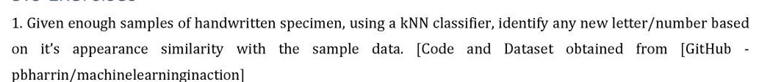

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
!git clone https://github.com/pbharrin/machinelearninginaction.git

Cloning into 'machinelearninginaction'...
remote: Enumerating objects: 319, done.
remote: Total 319 (delta 0), reused 0 (delta 0), pack-reused 319 (from 1)
Receiving objects: 100% (319/319), 15.26 MiB | 16.22 MiB/s, done.
Resolving deltas: 100% (114/114), done.


In [3]:
!ls machinelearninginaction/Ch02

datingTestSet2.txt  datingTestSet.txt  digits.zip  EXTRAS  kNN.py  README.txt


In [4]:
train_path = "machinelearninginaction/Ch02/trainingDigits"
test_path = "machinelearninginaction/Ch02/testDigits"

In [5]:
def img2vector(filename):
    vector = np.zeros((1, 1024))

    with open(filename, 'r') as f:
        for i in range(32):
            line = f.readline().strip()

            for j in range(32):
                vector[0, 32*i+j] = int(line[j])

    return vector

In [22]:
!wget -q https://github.com/pbharrin/machinelearninginaction/archive/refs/heads/master.zip
!unzip -q master.zip
!find machinelearninginaction-master -type d -name "trainingDigits"
!find machinelearninginaction-master -type d -name "testDigits"

In [23]:
!find machinelearninginaction-master -type f -name "digits.zip"

machinelearninginaction-master/Ch02/digits.zip
machinelearninginaction-master/Ch06/digits.zip


In [25]:
!find machinelearninginaction-master -type d -name "trainingDigits"
!find machinelearninginaction-master -type d -name "testDigits"

machinelearninginaction-master/Ch02/trainingDigits
machinelearninginaction-master/Ch02/testDigits


In [26]:
train_path = "machinelearninginaction-master/Ch02/trainingDigits"
test_path = "machinelearninginaction-master/Ch02/testDigits"

In [27]:
import os

print("Training files:", len(os.listdir(train_path)))
print("Testing files:", len(os.listdir(test_path)))
print("Sample files:", os.listdir(train_path)[:5])

Training files: 1934
Testing files: 946
Sample files: ['8_172.txt', '7_90.txt', '3_169.txt', '2_155.txt', '9_40.txt']


In [29]:
import numpy as np

def img2vector(filename):
    vector = np.zeros((1, 1024))

    with open(filename, 'r') as f:
        for i in range(32):
            line = f.readline().strip()
            for j in range(32):
                vector[0, 32*i + j] = int(line[j])

    return vector

In [30]:
from os import listdir

train_files = listdir(train_path)

X_train = np.zeros((len(train_files), 1024))
y_train = []

for i, filename in enumerate(train_files):
    label = int(filename.split('_')[0])
    y_train.append(label)
    X_train[i, :] = img2vector(
        train_path + "/" + filename
    )

y_train = np.array(y_train)

print("Training samples:", len(X_train))
print("Features:", X_train.shape[1])

Training samples: 1934
Features: 1024


In [31]:
test_files = listdir(test_path)

X_test = np.zeros((len(test_files), 1024))
y_test = []

for i, filename in enumerate(test_files):
    label = int(filename.split('_')[0])
    y_test.append(label)
    X_test[i, :] = img2vector(
        test_path + "/" + filename
    )

y_test = np.array(y_test)

print("Testing samples:", len(X_test))
print("Features:", X_test.shape[1])

Testing samples: 946
Features: 1024


In [32]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean'
)

model.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [33]:
y_pred = model.predict(X_test)

print("Predicted digits:")
print(y_pred[:20])

Predicted digits:
[7 9 8 2 1 1 8 6 7 6 5 9 2 8 2 0 6 6 9 1]


In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9873150105708245
Accuracy Percentage: 98.73150105708245 %


Actual Digit: 7
Predicted Digit: 7


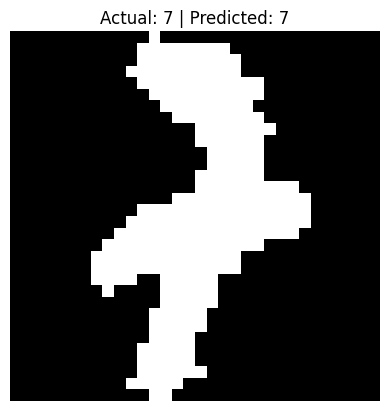

In [35]:
import matplotlib.pyplot as plt

index = 0

actual = y_test[index]
predicted = model.predict(X_test[index].reshape(1, -1))[0]

print("Actual Digit:", actual)
print("Predicted Digit:", predicted)

plt.imshow(X_test[index].reshape(32, 32), cmap='gray')
plt.title("Actual: " + str(actual) +
          " | Predicted: " + str(predicted))
plt.axis('off')
plt.show()

Actual Digit: 7
Predicted Digit: 7


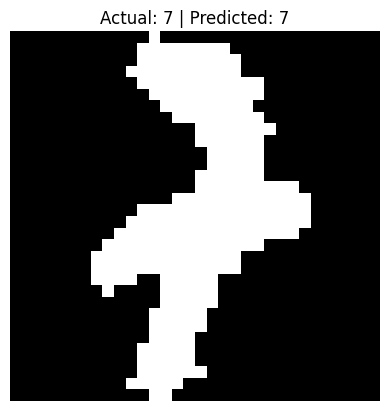

In [36]:
import matplotlib.pyplot as plt

index = 0

actual = y_test[index]
predicted = model.predict(X_test[index].reshape(1, -1))[0]

print("Actual Digit:", actual)
print("Predicted Digit:", predicted)

plt.imshow(X_test[index].reshape(32, 32), cmap='gray')
plt.title("Actual: " + str(actual) +
          " | Predicted: " + str(predicted))
plt.axis('off')
plt.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.96      0.99      0.97        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       0.99      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.95      0.97        91
           9       0.99      0.97      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.96      0.99      0.97        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       0.99      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.95      0.97        91
           9       0.99      0.97      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



In [39]:
index = 0

new_image = X_test[index].reshape(1, -1)

prediction = model.predict(new_image)

actual = y_test[index]

print("Actual Digit:", actual)
print("Predicted Digit:", prediction[0])

Actual Digit: 7
Predicted Digit: 7


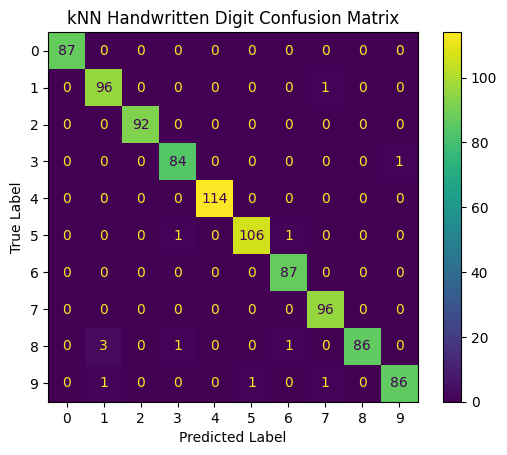

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot()
plt.title("kNN Handwritten Digit Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()